<a href="https://colab.research.google.com/github/masonfarley18/CPSC-392/blob/main/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

data = pd.read_csv(
    "https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/boutique.csv"
)

data = data.dropna().reset_index(drop=True)

X = data.drop(columns=["amount_spent_annual"])
y = data["amount_spent_annual"]

continuous = [
    "age",
    "height_cm",
    "waist_size_cm",
    "inseam_cm",
    "salary_self_report_in_k",
    "months_active",
    "num_purchases"
]

categorical = [
    "gender",
    "test_group"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            StandardScaler(),
            continuous
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical
        )
    ]
)

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Polynomial Degree 2": Pipeline([
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(degree=2)),
        ("model", LinearRegression())
    ]),

    "Polynomial Degree 3": Pipeline([
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(degree=3)),
        ("model", LinearRegression())
    ]),

    "Polynomial Degree 4": Pipeline([
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(degree=4)),
        ("model", LinearRegression())
    ]),

    "Polynomial Interaction Only": Pipeline([
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(
            degree=2,
            interaction_only=True
        )),
        ("model", LinearRegression())
    ])
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,

        "Train MSE": train_mse,
        "Test MSE": test_mse,

        "Train MAE": train_mae,
        "Test MAE": test_mae,

        "Train MAPE": train_mape,
        "Test MAPE": test_mape,

        "Train R²": train_r2,
        "Test R²": test_r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train MSE,Test MSE,Train MAE,Test MAE,Train MAPE,Test MAPE,Train R²,Test R²
0,Linear Regression,15385.643379,15354.246532,97.886353,97.847642,0.139360,0.139080,0.430910,0.443697
1,Polynomial Degree 2,5511.632294,5549.178675,59.643835,60.038589,0.079966,0.080961,0.796134,0.798946
2,Polynomial Degree 3,5441.557648,5629.470159,59.212406,60.404744,0.079336,0.081664,0.798726,0.796037
3,Polynomial Degree 4,5282.611567,5890.391678,58.239922,61.906285,0.077692,0.084162,0.804605,0.786584
4,Polynomial Interaction Only,15268.014830,15338.639581,97.557256,97.781896,0.138772,0.139008,0.435261,0.444262


The Linear Regression model seems to have the highest bias because it has the highest Train and Test MSE (15,385.64 and 15,354.25), meaning it has the most error on both the training and testing data.

The Polynomial Degree 4 model seems to have the highest variance and therefore greatest risk of overfitting because it has a very low training MSE of 5,282.61 but a much higher testing MSE of 5,890.39 (i.e the Train MSE and Test MSE for the Polynomial Degree 4 has the greatest gap compared to the rest of the models). This means that the model does not generalize well to new, unseen data.

Polynomial Degree 2 provides the best balance between bias and variance because its Training MSE (5,511.63) and its Testing MSE (5,549.18) are extremely similar. Its training and testing R^2 values are also very close (0.7961 and 0.7989), meaning the model generalizes well to new data without overfitting.

In [1]:
from plotnine import *

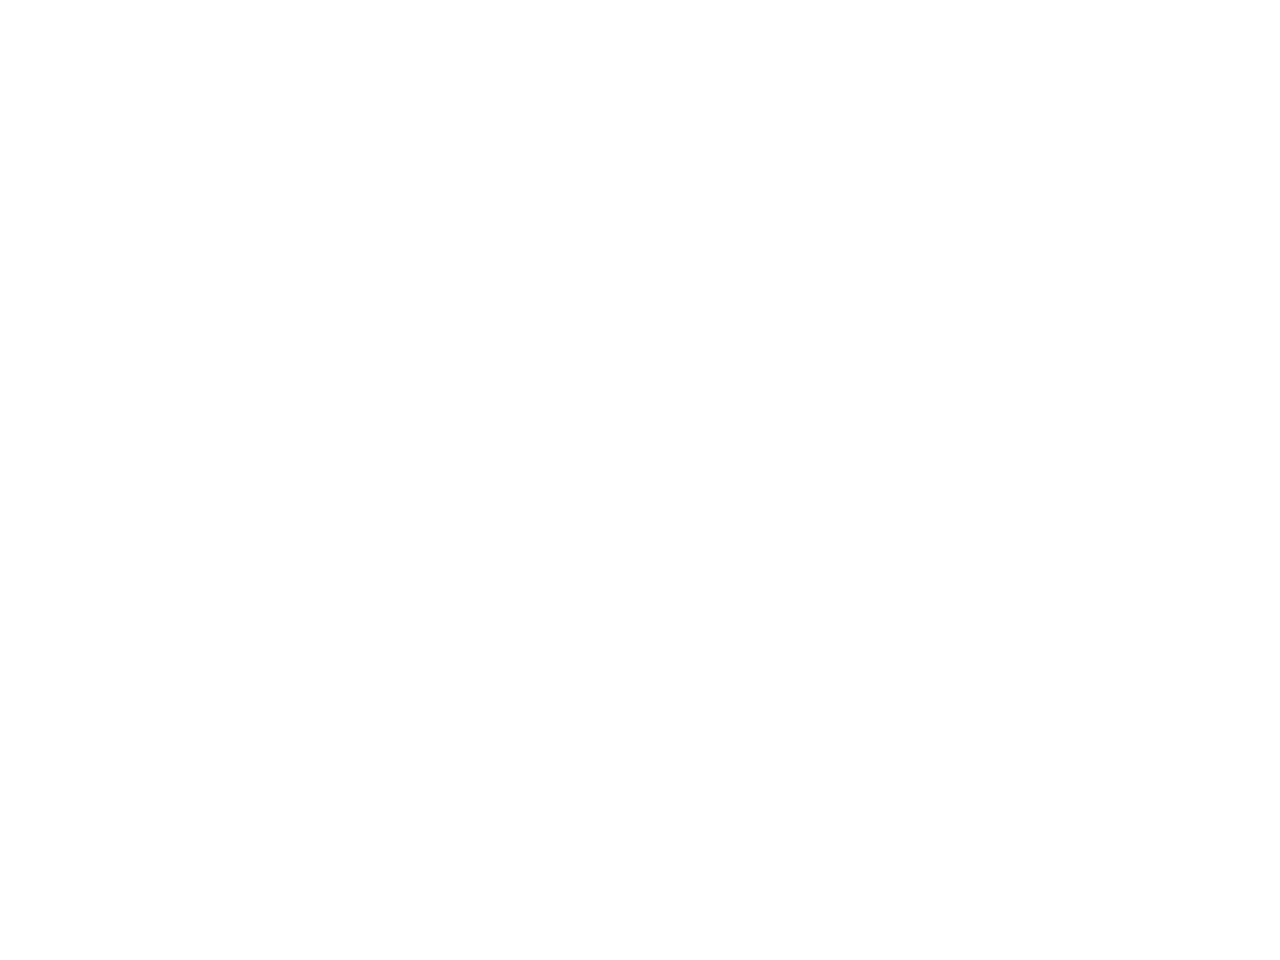

In [13]:
#1
data["test_group"] = data["test_group"].map({
    0: "Control",
    1: "Experimental"
})

ggplot(data, aes(x="test_group", y="amount_spent_annual", fill="gender")) \
    + geom_boxplot() \
    + labs(
        x="Test Group",
        y="Annual Amount Spent",
        title="Annual Spending by Test Group and Gender"
    )

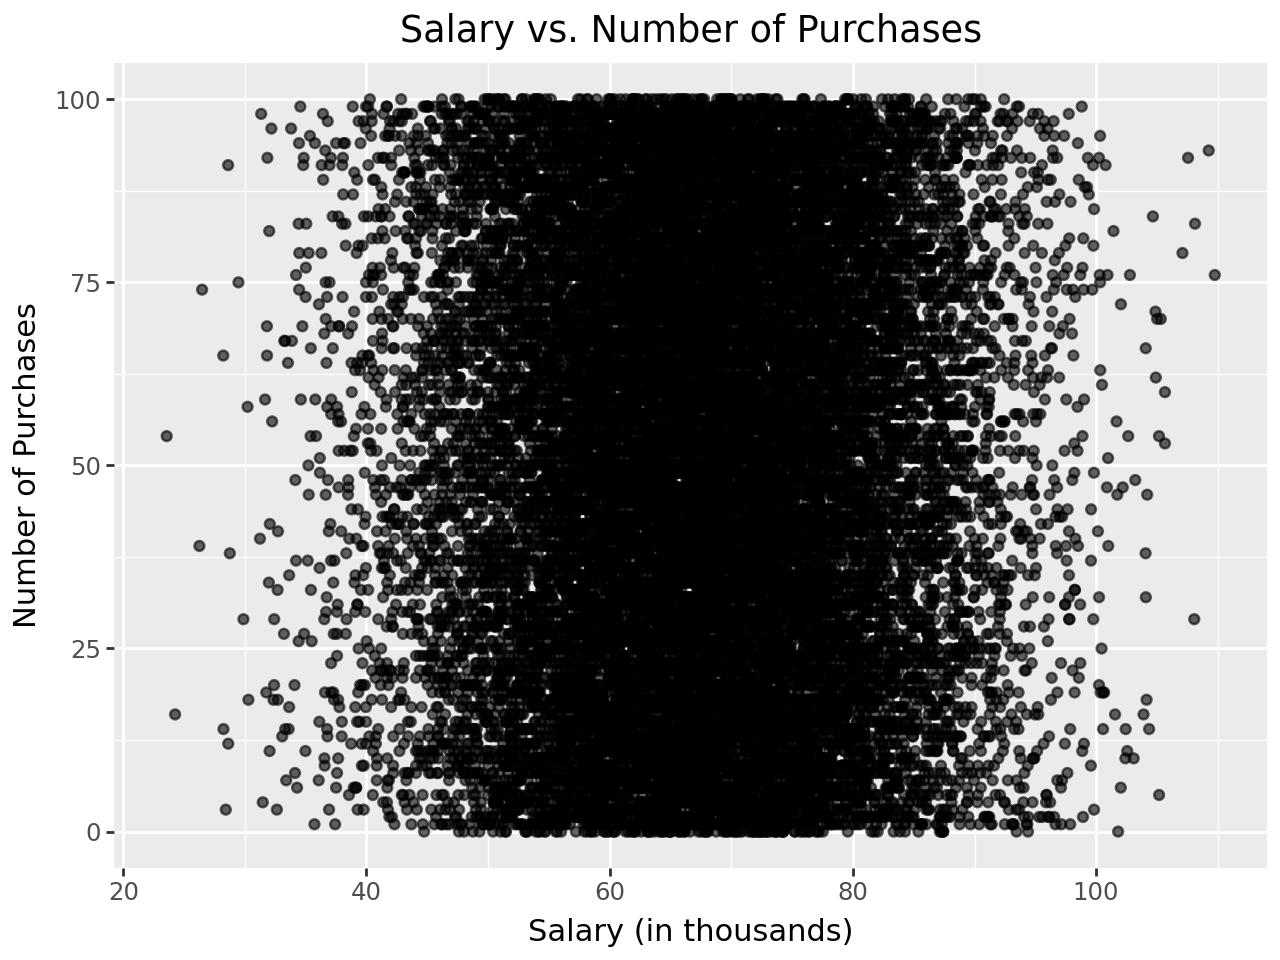

In [12]:
#2a
ggplot(data, aes(x="salary_self_report_in_k",
                 y="num_purchases",)) \
    + geom_point(alpha=0.6) \
    + labs(
        x="Salary (in thousands)",
        y="Number of Purchases",
        title="Salary vs. Number of Purchases"
    )

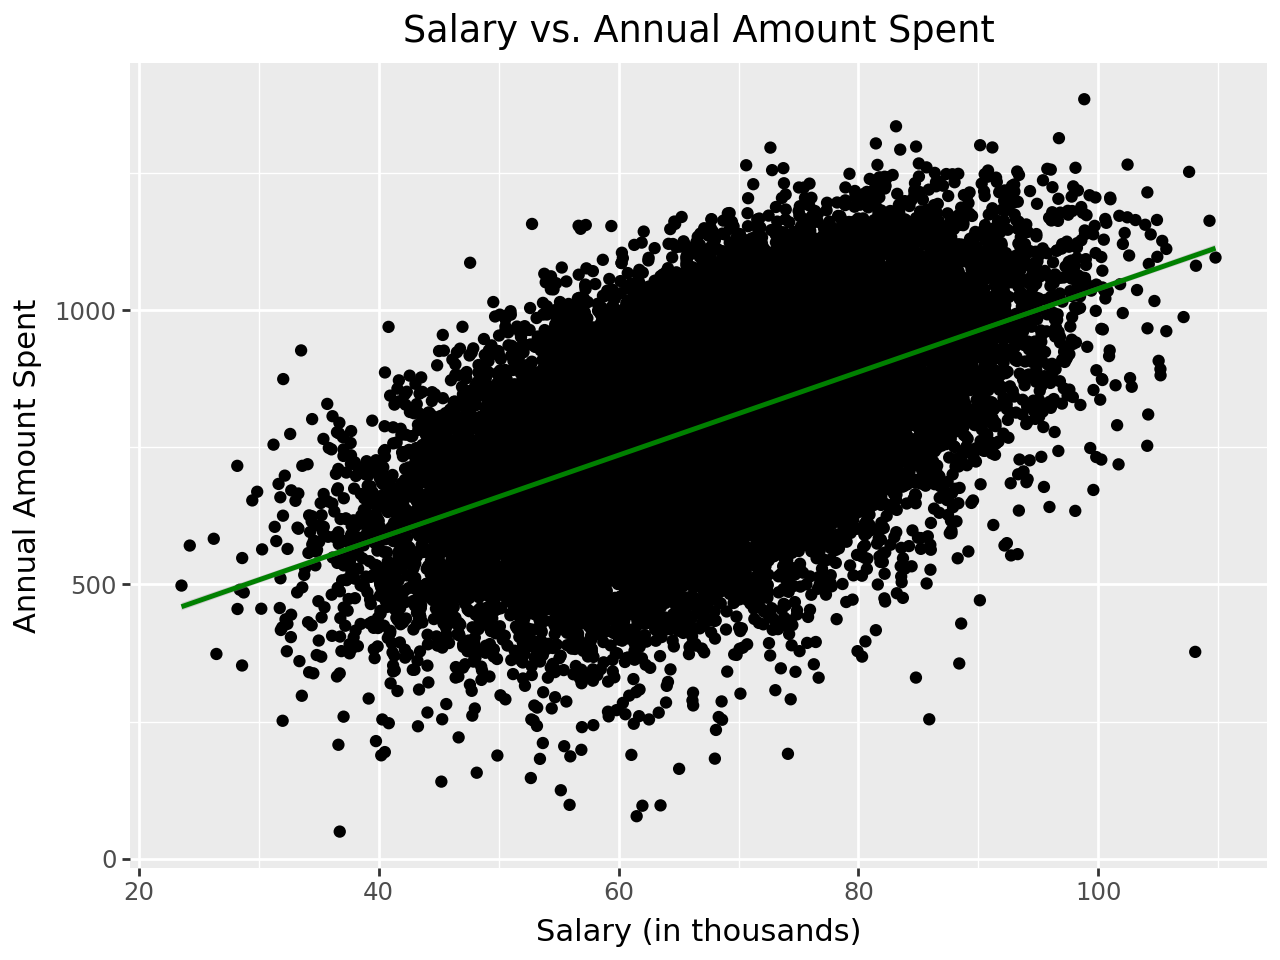

In [16]:
#2b
ggplot(data, aes(x="salary_self_report_in_k", y="amount_spent_annual")) \
    + geom_point() \
    + geom_smooth(method="lm", color = "green") \
    + labs(
        x="Salary (in thousands)",
        y="Annual Amount Spent",
        title="Salary vs. Annual Amount Spent"
    )

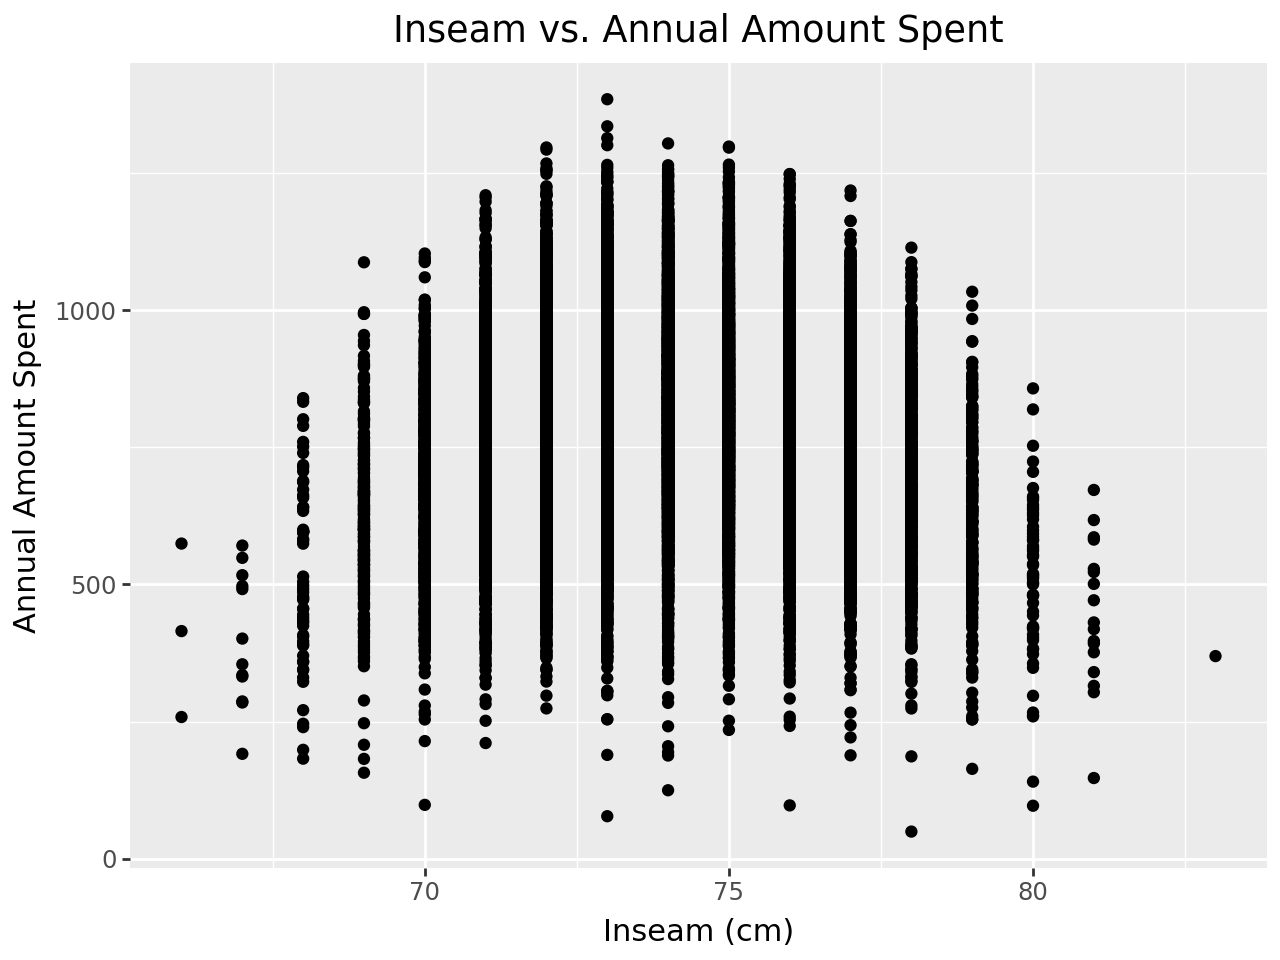

In [17]:
#3a
ggplot(data, aes(x="inseam_cm", y="amount_spent_annual")) \
    + geom_point() \
    + labs(
        x="Inseam (cm)",
        y="Annual Amount Spent",
        title="Inseam vs. Annual Amount Spent"
    )

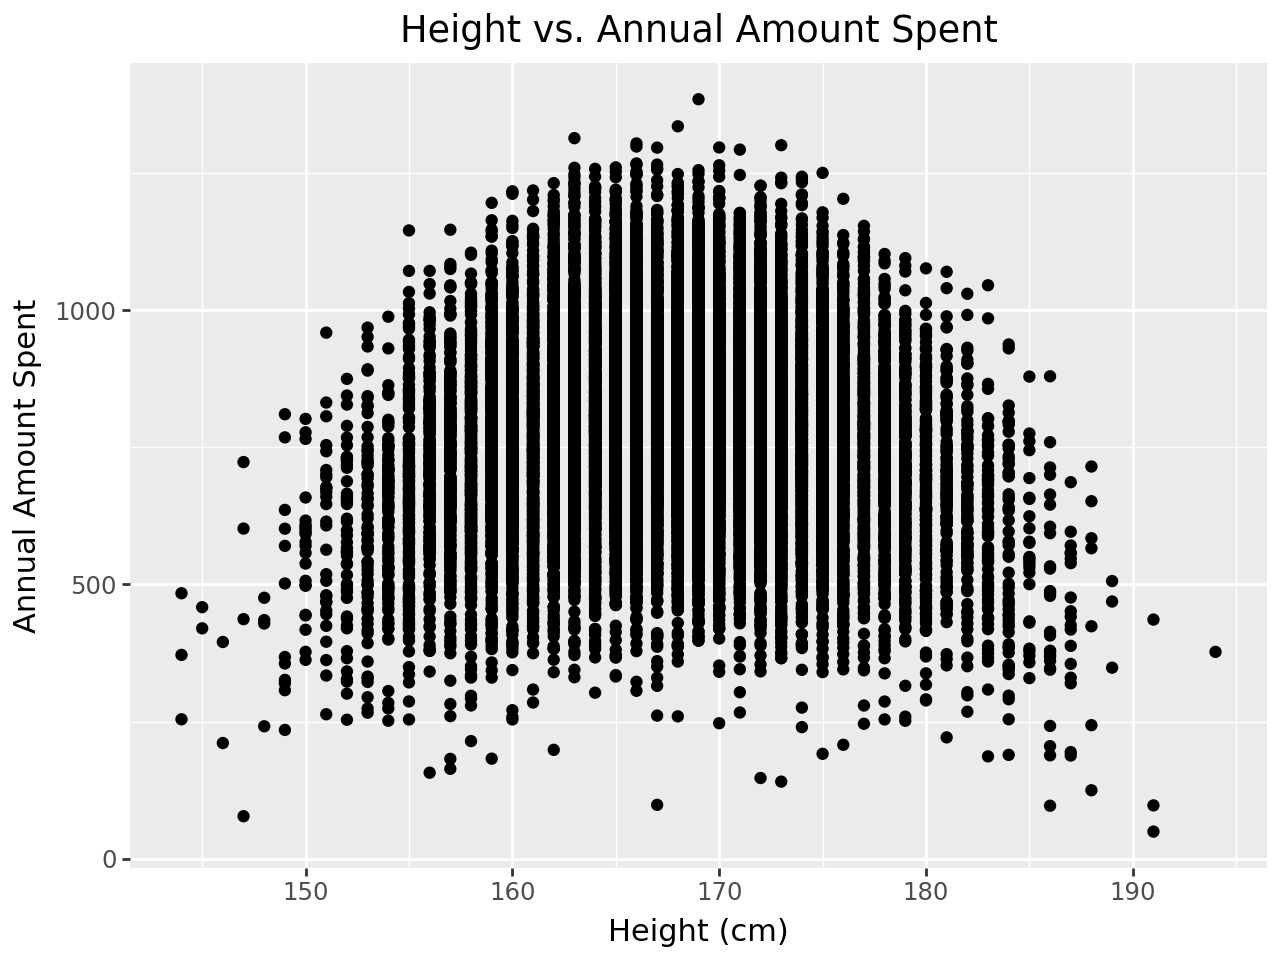

In [18]:
#3b
ggplot(data, aes(x="height_cm", y="amount_spent_annual")) \
    + geom_point() \
    + labs(
        x="Height (cm)",
        y="Annual Amount Spent",
        title="Height vs. Annual Amount Spent"
    )